<a href="https://colab.research.google.com/github/neha-sharma4/ML-2_Lab/blob/main/ML_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- After Example 1 (('Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same') -> Yes) ---
S (specific boundary):
   ('Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same')
G (general boundary):
   ('?', '?', '?', '?', '?', '?')

--- After Example 2 (('Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same') -> Yes) ---
S (specific boundary):
   ('Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same')
G (general boundary):
   ('?', '?', '?', '?', '?', '?')

--- After Example 3 (('Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change') -> No) ---
S (specific boundary):
   ('Sunny', 'Warm', '?', 'Strong', 'Warm', 'Same')
G (general boundary):
   ('?', 'Warm', '?', '?', '?', '?')
   ('?', '?', '?', '?', '?', 'Same')
   ('Sunny', '?', '?', '?', '?', '?')

--- After Example 4 (('Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change') -> Yes) ---
S (specific boundary):
   ('Sunny', 'Warm', '?', 'Strong', '?', '?')
G (general boundary):
   ('?', 'Warm', '?', '?', '?', '?')
   ('Sunny', '?', '?', '?', '?', '?')

FINAL SP

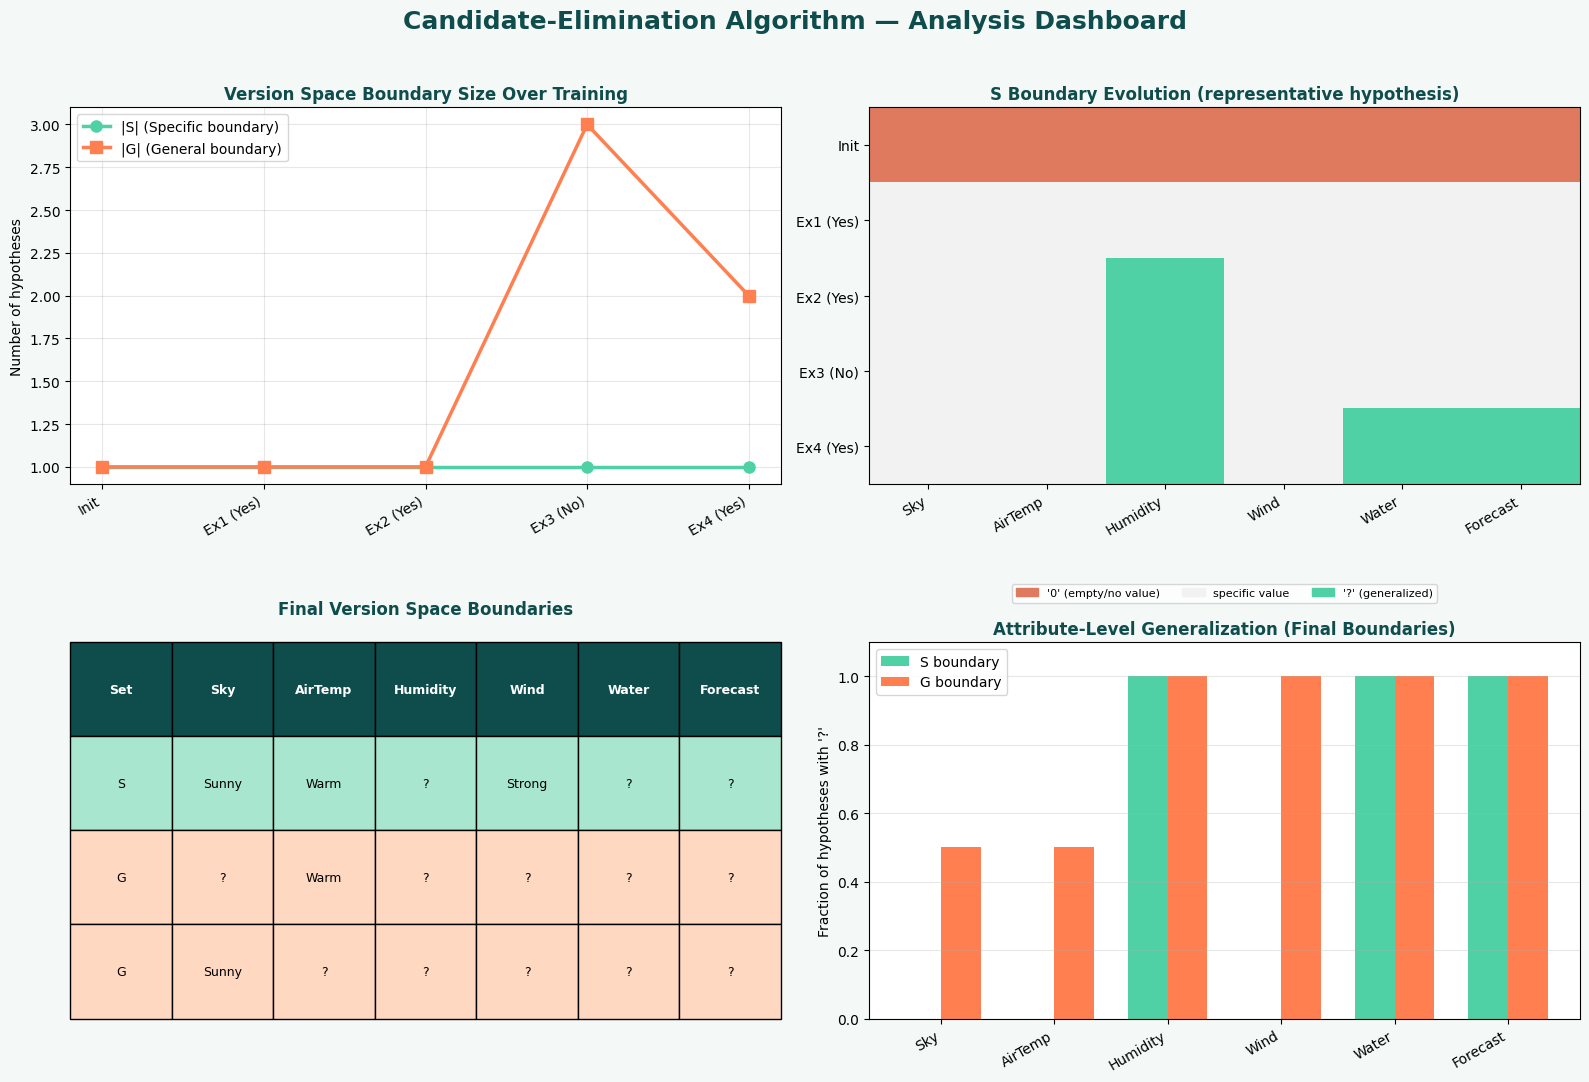


Saved visualization to candidate_elimination_analysis.png


In [1]:
"""
Candidate-Elimination Algorithm
Dataset: EnjoySport
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap


# =========================================================
# 1. DATASET
# =========================================================

# Attributes:
# Sky, AirTemp, Humidity, Wind, Water, Forecast

attributes = [
    'Sky',
    'AirTemp',
    'Humidity',
    'Wind',
    'Water',
    'Forecast'
]

data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same',   'Yes'],
    ['Sunny', 'Warm', 'High',   'Strong', 'Warm', 'Same',   'Yes'],
    ['Rainy', 'Cold', 'High',   'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High',   'Strong', 'Cool', 'Change', 'Yes']
]

X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n_attributes = len(attributes)


# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def more_general(h1, h2):
    """
    Return True if h1 is more general than or equal to h2.
    """

    for x, y_ in zip(h1, h2):

        if x == '?':
            continue

        if x == '0':
            return False

        if x != y_ and y_ != '0':
            return False

    return True


def consistent(h, instance):
    """
    Check whether hypothesis h matches the instance.
    """

    for hx, ix in zip(h, instance):

        if hx == '?':
            continue

        if hx != ix:
            return False

    return True


def min_generalizations(h, instance):
    """
    Return minimal generalizations of h
    that match the positive instance.
    """

    new_h = list(h)

    for i in range(len(h)):

        if h[i] == '0':
            new_h[i] = instance[i]

        elif h[i] != instance[i]:
            new_h[i] = '?'

    return [tuple(new_h)]


def min_specializations(h, domains, instance):
    """
    Return minimal specializations of h
    that do NOT match the negative instance.
    """

    results = []

    for i in range(len(h)):

        if h[i] == '?':

            for val in domains[i]:

                if val != instance[i]:

                    new_h = list(h)
                    new_h[i] = val

                    results.append(tuple(new_h))

        elif h[i] != '0':

            new_h = list(h)
            new_h[i] = '0'

            results.append(tuple(new_h))

    return results


def remove_more_general(hyps):
    """
    Remove hypotheses that are more general than another.
    Used for the Specific boundary S.
    """

    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h2, h)
            for h2 in hyps
        )
    ]


def remove_less_general(hyps):
    """
    Remove hypotheses that are less general than another.
    Used for the General boundary G.
    """

    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h, h2)
            for h2 in hyps
        )
    ]


# =========================================================
# 3. CANDIDATE-ELIMINATION ALGORITHM
# =========================================================

def candidate_elimination(X, y, attributes):

    # Find possible values for every attribute
    domains = [
        sorted(set(row[i] for row in X))
        for i in range(len(attributes))
    ]

    # Initial boundaries
    # S = maximally specific hypothesis
    S = [
        tuple(['0'] * n_attributes)
    ]

    # G = maximally general hypothesis
    G = [
        tuple(['?'] * n_attributes)
    ]

    # Store history for visualization
    history = {
        'S_sizes': [len(S)],
        'G_sizes': [len(G)],
        'S_sets': [list(S)],
        'G_sets': [list(G)],
        'labels': ['Init']
    }

    # Process every training example
    for idx, (instance, label) in enumerate(zip(X, y)):

        instance = tuple(instance)

        # -------------------------------------------------
        # POSITIVE EXAMPLE
        # -------------------------------------------------

        if label == 'Yes':

            # Remove hypotheses from G
            # that don't cover the positive example
            G = [
                g for g in G
                if consistent(g, instance)
            ]

            new_S = []

            for s in S:

                # If S already covers the example
                if consistent(s, instance):

                    new_S.append(s)

                else:

                    # Generalize S minimally
                    generalizations = min_generalizations(
                        s,
                        instance
                    )

                    for h in generalizations:

                        # Keep h only if some G hypothesis
                        # is more general than h
                        if any(
                            more_general(g, h)
                            for g in G
                        ):
                            new_S.append(h)

            S = remove_more_general(
                list(set(new_S))
            )

        # -------------------------------------------------
        # NEGATIVE EXAMPLE
        # -------------------------------------------------

        else:

            # Remove hypotheses from S
            # that incorrectly classify this example
            S = [
                s for s in S
                if not consistent(s, instance)
            ]

            new_G = []

            for g in G:

                # If G doesn't cover the negative example
                # then keep it
                if not consistent(g, instance):

                    new_G.append(g)

                else:

                    # Specialize G minimally
                    specializations = min_specializations(
                        g,
                        domains,
                        instance
                    )

                    for h in specializations:

                        # Keep h only if it is
                        # more general than some S
                        if any(
                            more_general(h, s)
                            for s in S
                        ):
                            new_G.append(h)

            G = remove_less_general(
                list(set(new_G))
            )

        # -------------------------------------------------
        # SAVE HISTORY
        # -------------------------------------------------

        history['S_sizes'].append(len(S))
        history['G_sizes'].append(len(G))

        history['S_sets'].append(list(S))
        history['G_sets'].append(list(G))

        history['labels'].append(
            f'Ex{idx + 1} ({label})'
        )

        # -------------------------------------------------
        # PRINT CURRENT BOUNDARIES
        # -------------------------------------------------

        print(
            f"\n--- After Example {idx + 1} "
            f"({instance} -> {label}) ---"
        )

        print("S (specific boundary):")

        for s in S:
            print("  ", s)

        print("G (general boundary):")

        for g in G:
            print("  ", g)

    return S, G, history


# =========================================================
# 4. RUN ALGORITHM
# =========================================================

S_final, G_final, history = candidate_elimination(
    X,
    y,
    attributes
)


# =========================================================
# 5. FINAL RESULT
# =========================================================

print("\n============================")

print("FINAL SPECIFIC BOUNDARY (S):")

for s in S_final:
    print("  ", s)

print("\nFINAL GENERAL BOUNDARY (G):")

for g in G_final:
    print("  ", g)


# =========================================================
# 6. VISUALIZATION SETTINGS
# =========================================================

COL_TEAL = '#0f4c4c'
COL_MINT = '#4fd1a5'
COL_LIGHT = '#a8e6cf'
COL_ACCENT = '#ff7f50'
COL_BG = '#f4f9f8'


def specificity_score(h):
    """
    Convert a hypothesis into numerical values.

    0  -> specific attribute value
    1  -> '?'
    -1 -> '0'
    """

    return [
        -1 if v == '0'
        else 1 if v == '?'
        else 0
        for v in h
    ]


# =========================================================
# 7. CREATE ANALYSIS DASHBOARD
# =========================================================

fig = plt.figure(
    figsize=(16, 11),
    facecolor=COL_BG
)

fig.suptitle(
    'Candidate-Elimination Algorithm — Analysis Dashboard',
    fontsize=18,
    fontweight='bold',
    color=COL_TEAL,
    y=0.98
)


# =========================================================
# PLOT 1
# S AND G BOUNDARY SIZE TREND
# =========================================================

ax1 = plt.subplot(2, 2, 1)

steps = range(
    len(history['S_sizes'])
)

ax1.plot(
    steps,
    history['S_sizes'],
    marker='o',
    color=COL_MINT,
    linewidth=2.5,
    label='|S| (Specific boundary)',
    markersize=8
)

ax1.plot(
    steps,
    history['G_sizes'],
    marker='s',
    color=COL_ACCENT,
    linewidth=2.5,
    label='|G| (General boundary)',
    markersize=8
)

ax1.set_xticks(steps)

ax1.set_xticklabels(
    history['labels'],
    rotation=30,
    ha='right'
)

ax1.set_ylabel(
    'Number of hypotheses'
)

ax1.set_title(
    'Version Space Boundary Size Over Training',
    color=COL_TEAL,
    fontweight='bold'
)

ax1.legend()

ax1.grid(alpha=0.3)

ax1.set_facecolor('white')


# =========================================================
# PLOT 2
# SPECIFIC BOUNDARY EVOLUTION
# =========================================================

ax2 = plt.subplot(2, 2, 2)

s_track = []

for s_set in history['S_sets']:

    if s_set:

        h = s_set[0]

    else:

        h = tuple(
            ['0'] * n_attributes
        )

    s_track.append(
        specificity_score(h)
    )


s_matrix = np.array(s_track)


cmap = ListedColormap([
    '#e07a5f',
    '#f2f2f2',
    COL_MINT
])


im = ax2.imshow(
    s_matrix,
    aspect='auto',
    cmap=cmap,
    vmin=-1,
    vmax=1
)


ax2.set_xticks(
    range(n_attributes)
)

ax2.set_xticklabels(
    attributes,
    rotation=30,
    ha='right'
)

ax2.set_yticks(
    range(len(history['labels']))
)

ax2.set_yticklabels(
    history['labels']
)

ax2.set_title(
    'S Boundary Evolution (representative hypothesis)',
    color=COL_TEAL,
    fontweight='bold'
)


patches = [

    mpatches.Patch(
        color='#e07a5f',
        label="'0' (empty/no value)"
    ),

    mpatches.Patch(
        color='#f2f2f2',
        label='specific value'
    ),

    mpatches.Patch(
        color=COL_MINT,
        label="'?' (generalized)"
    )
]


ax2.legend(
    handles=patches,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    fontsize=8
)


# =========================================================
# PLOT 3
# FINAL S VS G TABLE
# =========================================================

ax3 = plt.subplot(2, 2, 3)

ax3.axis('off')

ax3.set_title(
    'Final Version Space Boundaries',
    color=COL_TEAL,
    fontweight='bold',
    pad=20
)


table_data = []

row_colors = []


for s in S_final:

    table_data.append(
        ['S'] + list(s)
    )

    row_colors.append(
        COL_LIGHT
    )


for g in G_final:

    table_data.append(
        ['G'] + list(g)
    )

    row_colors.append(
        '#ffd8c2'
    )


col_labels = [
    'Set'
] + attributes


tbl = ax3.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
    bbox=[0, 0, 1, 1]
)


tbl.auto_set_font_size(False)

tbl.set_fontsize(9)


# Color rows
for i, color in enumerate(row_colors):

    for j in range(len(col_labels)):

        tbl[
            (i + 1, j)
        ].set_facecolor(color)


# Color header
for j in range(len(col_labels)):

    tbl[
        (0, j)
    ].set_facecolor(COL_TEAL)

    tbl[
        (0, j)
    ].set_text_props(
        color='white',
        fontweight='bold'
    )


# =========================================================
# PLOT 4
# ATTRIBUTE-LEVEL GENERALITY
# =========================================================

ax4 = plt.subplot(2, 2, 4)


s_generality = np.mean(
    [
        [
            1 if v == '?' else 0
            for v in s
        ]
        for s in S_final
    ],
    axis=0
)


g_generality = np.mean(
    [
        [
            1 if v == '?' else 0
            for v in g
        ]
        for g in G_final
    ],
    axis=0
)


x_pos = np.arange(
    n_attributes
)

width = 0.35


ax4.bar(
    x_pos - width / 2,
    s_generality,
    width,
    label='S boundary',
    color=COL_MINT
)


ax4.bar(
    x_pos + width / 2,
    g_generality,
    width,
    label='G boundary',
    color=COL_ACCENT
)


ax4.set_xticks(
    x_pos
)

ax4.set_xticklabels(
    attributes,
    rotation=30,
    ha='right'
)

ax4.set_ylabel(
    "Fraction of hypotheses with '?'"
)

ax4.set_title(
    'Attribute-Level Generalization (Final Boundaries)',
    color=COL_TEAL,
    fontweight='bold'
)

ax4.legend()

ax4.grid(
    alpha=0.3,
    axis='y'
)

ax4.set_ylim(
    0,
    1.1
)

ax4.set_facecolor(
    'white'
)


# =========================================================
# 8. DISPLAY AND SAVE
# =========================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.savefig(
    'candidate_elimination_analysis.png',
    dpi=150,
    facecolor=COL_BG
)

plt.show()

print(
    "\nSaved visualization to "
    "candidate_elimination_analysis.png"
)


Example 1
Instance : ('Sunny', 'Hot', 'High', 'Weak')
Label    : No

Specific Boundary S:
   ('0', '0', '0', '0')

General Boundary G:
   ('?', '?', 'Normal', '?')
   ('?', 'Cool', '?', '?')
   ('Rain', '?', '?', '?')
   ('Overcast', '?', '?', '?')
   ('?', '?', '?', 'Strong')
   ('?', 'Mild', '?', '?')

Example 2
Instance : ('Sunny', 'Hot', 'High', 'Strong')
Label    : No

Specific Boundary S:
   ('0', '0', '0', '0')

General Boundary G:
   ('?', '?', 'Normal', 'Strong')
   ('Overcast', '?', '?', 'Strong')
   ('Rain', '?', '?', 'Strong')
   ('?', 'Cool', '?', 'Strong')
   ('?', 'Mild', '?', 'Strong')

Example 3
Instance : ('Overcast', 'Hot', 'High', 'Weak')
Label    : Yes

Specific Boundary S:
   Empty

General Boundary G:
   Empty

Example 4
Instance : ('Rain', 'Mild', 'High', 'Weak')
Label    : Yes

Specific Boundary S:
   Empty

General Boundary G:
   Empty

Example 5
Instance : ('Rain', 'Cool', 'Normal', 'Weak')
Label    : Yes

Specific Boundary S:
   Empty

General Boundary G:
 

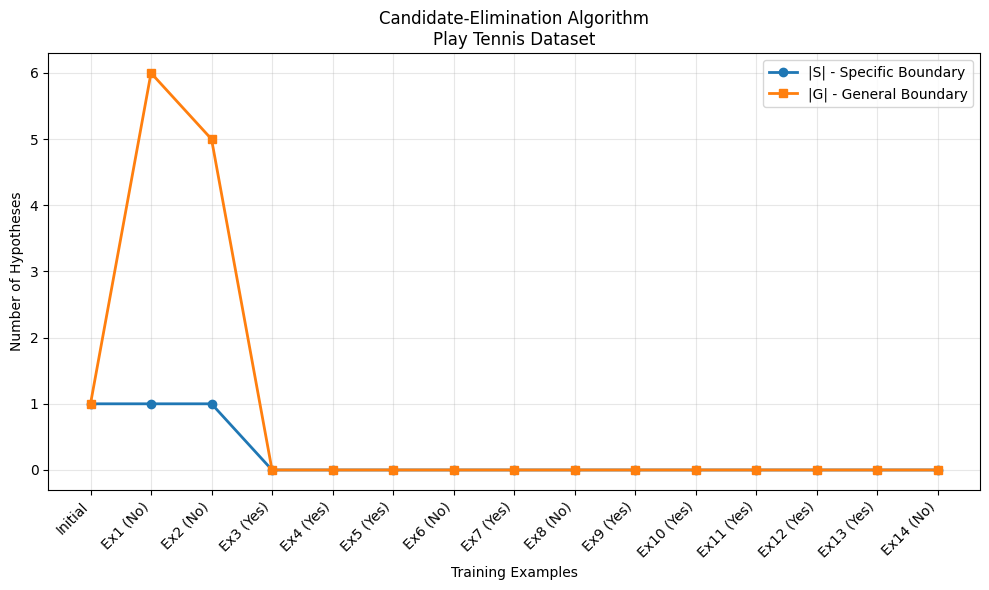


FINAL VERSION SPACE

Specific Boundary:
Set | Outlook | Temperature | Humidity | Wind
----------------------------------------------------------------------

General Boundary:
Set | Outlook | Temperature | Humidity | Wind
----------------------------------------------------------------------


In [2]:
# =========================================================
# CANDIDATE ELIMINATION ALGORITHM
# Dataset: Play Tennis
# =========================================================

import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 1. DATASET
# =========================================================

# Attributes:
# Outlook, Temperature, Humidity, Wind

attributes = [
    'Outlook',
    'Temperature',
    'Humidity',
    'Wind'
]

data = [
    ['Sunny',    'Hot',  'High',   'Weak',   'No'],
    ['Sunny',    'Hot',  'High',   'Strong', 'No'],
    ['Overcast', 'Hot',  'High',   'Weak',   'Yes'],
    ['Rain',     'Mild', 'High',   'Weak',   'Yes'],
    ['Rain',     'Cool', 'Normal', 'Weak',   'Yes'],
    ['Rain',     'Cool', 'Normal', 'Strong', 'No'],
    ['Overcast', 'Cool', 'Normal', 'Strong', 'Yes'],
    ['Sunny',    'Mild', 'High',   'Weak',   'No'],
    ['Sunny',    'Cool', 'Normal', 'Weak',   'Yes'],
    ['Rain',     'Mild', 'Normal', 'Weak',   'Yes'],
    ['Sunny',    'Mild', 'Normal', 'Strong', 'Yes'],
    ['Overcast', 'Mild', 'High',   'Strong', 'Yes'],
    ['Overcast', 'Hot',  'Normal', 'Weak',   'Yes'],
    ['Rain',     'Mild', 'High',   'Strong', 'No']
]

# Separate features and target
X = [row[:-1] for row in data]
y = [row[-1] for row in data]

n_attributes = len(attributes)


# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def more_general(h1, h2):
    """
    Check whether hypothesis h1 is more general than
    or equal to hypothesis h2.
    """

    for x, y_ in zip(h1, h2):

        # '?' can represent anything
        if x == '?':
            continue

        # '0' is the most specific value
        if x == '0':
            return False

        # If values differ, h1 cannot be more general
        if x != y_ and y_ != '0':
            return False

    return True


def consistent(h, instance):
    """
    Check whether hypothesis h correctly covers
    the given instance.
    """

    for hx, ix in zip(h, instance):

        # '?' matches every value
        if hx == '?':
            continue

        # Otherwise values must match
        if hx != ix:
            return False

    return True


def min_generalizations(h, instance):
    """
    Find minimal generalizations of hypothesis h
    so that it covers a positive instance.
    """

    new_h = list(h)

    for i in range(len(h)):

        # If attribute is completely specific,
        # replace it with the instance value
        if h[i] == '0':
            new_h[i] = instance[i]

        # If value does not match, generalize to '?'
        elif h[i] != instance[i]:
            new_h[i] = '?'

    return [tuple(new_h)]


def min_specializations(h, domains, instance):
    """
    Find minimal specializations of hypothesis h
    so that it does NOT cover a negative instance.
    """

    results = []

    for i in range(len(h)):

        # If attribute is generalized,
        # specialize it using values other than
        # the negative example's value
        if h[i] == '?':

            for val in domains[i]:

                if val != instance[i]:

                    new_h = list(h)
                    new_h[i] = val

                    results.append(tuple(new_h))

        # If it is not generalized, specialize it to '0'
        elif h[i] != '0':

            new_h = list(h)
            new_h[i] = '0'

            results.append(tuple(new_h))

    return results


def remove_more_general(hyps):
    """
    Remove hypotheses that are more general than
    another hypothesis.

    Used for the Specific boundary S.
    """

    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h2, h)
            for h2 in hyps
        )
    ]


def remove_less_general(hyps):
    """
    Remove hypotheses that are less general than
    another hypothesis.

    Used for the General boundary G.
    """

    return [
        h for h in hyps
        if not any(
            h != h2 and more_general(h, h2)
            for h2 in hyps
        )
    ]


# =========================================================
# 3. CANDIDATE ELIMINATION ALGORITHM
# =========================================================

def candidate_elimination(X, y, attributes):

    # Find all possible values for every attribute
    domains = [
        sorted(set(row[i] for row in X))
        for i in range(len(attributes))
    ]

    # -----------------------------------------------------
    # INITIAL BOUNDARIES
    # -----------------------------------------------------

    # Most specific hypothesis
    S = [
        tuple(['0'] * n_attributes)
    ]

    # Most general hypothesis
    G = [
        tuple(['?'] * n_attributes)
    ]

    # Store history
    history = {
        'S_sizes': [len(S)],
        'G_sizes': [len(G)],
        'S_sets': [list(S)],
        'G_sets': [list(G)],
        'labels': ['Initial']
    }

    # -----------------------------------------------------
    # PROCESS EACH TRAINING EXAMPLE
    # -----------------------------------------------------

    for idx, (instance, label) in enumerate(zip(X, y)):

        instance = tuple(instance)

        print("\n" + "=" * 70)
        print(f"Example {idx + 1}")
        print(f"Instance : {instance}")
        print(f"Label    : {label}")

        # =================================================
        # POSITIVE EXAMPLE
        # =================================================

        if label == 'Yes':

            # Remove G hypotheses that don't cover
            # this positive example
            G = [
                g for g in G
                if consistent(g, instance)
            ]

            new_S = []

            for s in S:

                # If S already covers the example
                if consistent(s, instance):

                    new_S.append(s)

                else:

                    # Generalize S minimally
                    generalizations = min_generalizations(
                        s,
                        instance
                    )

                    for h in generalizations:

                        # Keep only hypotheses that are
                        # still below at least one G
                        if any(
                            more_general(g, h)
                            for g in G
                        ):
                            new_S.append(h)

            # Remove duplicate hypotheses
            # and unnecessary general hypotheses
            S = remove_more_general(
                list(set(new_S))
            )

        # =================================================
        # NEGATIVE EXAMPLE
        # =================================================

        else:

            # Remove S hypotheses that cover
            # this negative example
            S = [
                s for s in S
                if not consistent(s, instance)
            ]

            new_G = []

            for g in G:

                # If G already rejects the negative example
                if not consistent(g, instance):

                    new_G.append(g)

                else:

                    # Specialize G minimally
                    specializations = min_specializations(
                        g,
                        domains,
                        instance
                    )

                    for h in specializations:

                        # Keep only hypotheses that are
                        # still above at least one S
                        if any(
                            more_general(h, s)
                            for s in S
                        ):
                            new_G.append(h)

            # Remove duplicate hypotheses
            # and unnecessary specific hypotheses
            G = remove_less_general(
                list(set(new_G))
            )

        # -------------------------------------------------
        # SAVE HISTORY
        # -------------------------------------------------

        history['S_sizes'].append(len(S))
        history['G_sizes'].append(len(G))

        history['S_sets'].append(list(S))
        history['G_sets'].append(list(G))

        history['labels'].append(
            f"Ex{idx + 1} ({label})"
        )

        # -------------------------------------------------
        # DISPLAY CURRENT BOUNDARIES
        # -------------------------------------------------

        print("\nSpecific Boundary S:")

        if len(S) == 0:
            print("   Empty")

        else:
            for s in S:
                print("  ", s)

        print("\nGeneral Boundary G:")

        if len(G) == 0:
            print("   Empty")

        else:
            for g in G:
                print("  ", g)


    return S, G, history


# =========================================================
# 4. RUN CANDIDATE ELIMINATION
# =========================================================

S_final, G_final, history = candidate_elimination(
    X,
    y,
    attributes
)


# =========================================================
# 5. FINAL RESULT
# =========================================================

print("\n\n")
print("=" * 70)
print("FINAL RESULT")
print("=" * 70)

print("\nFinal Specific Boundary (S):")

for s in S_final:
    print("  ", s)

print("\nFinal General Boundary (G):")

for g in G_final:
    print("  ", g)


# =========================================================
# 6. VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 6))

steps = range(len(history['S_sizes']))

plt.plot(
    steps,
    history['S_sizes'],
    marker='o',
    linewidth=2,
    label='|S| - Specific Boundary'
)

plt.plot(
    steps,
    history['G_sizes'],
    marker='s',
    linewidth=2,
    label='|G| - General Boundary'
)

plt.xticks(
    steps,
    history['labels'],
    rotation=45,
    ha='right'
)

plt.xlabel("Training Examples")
plt.ylabel("Number of Hypotheses")

plt.title(
    "Candidate-Elimination Algorithm\n"
    "Play Tennis Dataset"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# =========================================================
# 7. DISPLAY FINAL BOUNDARIES AS TABLE
# =========================================================

print("\n" + "=" * 70)
print("FINAL VERSION SPACE")
print("=" * 70)

print("\nSpecific Boundary:")

print(
    "Set | "
    + " | ".join(attributes)
)

print("-" * 70)

for s in S_final:

    print(
        " S  | "
        + " | ".join(s)
    )


print("\nGeneral Boundary:")

print(
    "Set | "
    + " | ".join(attributes)
)

print("-" * 70)

for g in G_final:

    print(
        " G  | "
        + " | ".join(g)
    )